In [566]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

In [567]:
# Set seed for reproducibility
np.random.seed(42)

# Load data
df = pd.read_csv('portugal_listinigs.csv')
df.head()

C:\Users\Cristiano\AppData\Local\Temp\ipykernel_12500\3582540689.py:5: DtypeWarning: Columns (6,8,12,13,14,15,16,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('portugal_listinigs.csv')


,Price,District,City,Town,Type,EnergyCertificate,Floor,Parking,HasParking,ConstructionYear,...,Elevator,ElectricCarsCharging,TotalRooms,NumberOfBedrooms,NumberOfWC,ConservationStatus,LivingArea,LotSize,BuiltArea,NumberOfBathrooms
0,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,2nd Floor,1.0,True,NaN,...,True,NaN,2.0,NaN,NaN,NaN,114.0,NaN,NaN,2.0
1,9500.0,Faro,Albufeira,Albufeira e Olhos de Água,Apartment,NC,1st Floor,0.0,False,1990.0,...,True,NaN,0.0,NaN,NaN,NaN,27.0,NaN,NaN,1.0
2,580000.0,Faro,Vila do Bispo,Budens,Apartment,D,3rd Floor,1.0,True,2003.0,...,False,NaN,2.0,NaN,NaN,NaN,84.0,NaN,NaN,2.0
3,350000.0,Faro,Portimão,Portimão,Apartment,C,4th Floor,0.0,False,1985.0,...,True,NaN,2.0,NaN,NaN,NaN,68.0,NaN,NaN,1.0
4,175000.0,Faro,Faro,Faro (Sé e São Pedro),House,NC,NaN,0.0,False,1950.0,...,False,NaN,4.0,NaN,NaN,NaN,78.0,NaN,NaN,2.0


In [568]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120826 entries, 0 to 120825
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Price                  120545 non-null  float64
 1   District               120826 non-null  object 
 2   City                   120826 non-null  object 
 3   Town                   120824 non-null  object 
 4   Type                   120810 non-null  object 
 5   EnergyCertificate      120812 non-null  object 
 6   Floor                  27929 non-null   object 
 7   Parking                120632 non-null  float64
 8   HasParking             68215 non-null   object 
 9   ConstructionYear       78228 non-null   float64
 10  TotalArea              113782 non-null  float64
 11  GrossArea              27638 non-null   float64
 12  EnergyEfficiencyLevel  52579 non-null   object 
 13  PublishDate            19224 non-null   object 
 14  Garage                 52579 non-nul

In [569]:
df.describe()

,Price,Parking,ConstructionYear,TotalArea,GrossArea,TotalRooms,NumberOfBedrooms,NumberOfWC,LivingArea,LotSize,BuiltArea,NumberOfBathrooms
count,1.205450e+05,120632.000000,78228.000000,1.137820e+05,2.763800e+04,67802.000000,35428.000000,46621.000000,9.252900e+04,3.209000e+04,2.097700e+04,115096.000000
mean,3.674658e+05,0.570520,1988.993596,5.742814e+05,2.789733e+03,3.151220,2.680253,0.412196,1.508726e+03,6.726420e+04,3.495683e+03,1.516273
std,4.024606e+06,0.870374,26.690061,1.821361e+08,1.153670e+05,10.880886,1.863235,1.021265,3.684470e+04,5.784162e+06,1.321013e+05,1.719349
min,1.000000e+00,0.000000,1900.000000,-7.196067e+06,-7.000000e+00,0.000000,0.000000,-15.000000,0.000000e+00,0.000000e+00,-1.000000e+00,-13.000000
25%,7.990000e+04,0.000000,1972.000000,9.400000e+01,1.000000e+02,2.000000,2.000000,0.000000,8.000000e+01,2.880000e+02,1.058000e+02,0.000000
50%,2.000000e+05,0.000000,1994.000000,1.710000e+02,1.640000e+02,3.000000,3.000000,0.000000,1.200000e+02,7.565000e+02,1.730000e+02,1.000000
75%,3.921000e+05,1.000000,2008.000000,5.800000e+02,2.940000e+02,4.000000,3.000000,0.000000,2.120000e+02,3.174750e+03,3.114500e+02,2.000000
max,1.380000e+09,3.000000,2024.000000,6.142007e+10,1.275000e+07,2751.000000,21.000000,59.000000,5.429000e+06,9.923010e+08,1.275000e+07,90.000000


In [570]:
# Drop values bellow 0 or 0 in the columns where that is not possible
df.drop(df[df['TotalArea'] <= 0].index, inplace=True)
df.drop(df[df['GrossArea'] <= 0].index, inplace=True)
df.drop(df[df['BuiltArea'] <= 0].index, inplace=True)
df.drop(df[df['NumberOfBathrooms'] < 0].index, inplace=True)
df.drop(df[df['NumberOfWC'] < 0].index, inplace=True)

In [571]:
def show_missing_data_with_percent(df):
    missing_values = df.isna().sum()
    missing_percentage = round((df.isna().sum() / len(df)) * 100, 2)
    missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
    print(missing_data)
show_missing_data_with_percent(df)

                       Missing Values  Percentage
Price                             279        0.23
District                            0        0.00
City                                0        0.00
Town                                2        0.00
Type                               16        0.01
EnergyCertificate                  14        0.01
Floor                           92307       77.17
Parking                           194        0.16
HasParking                      52262       43.69
ConstructionYear                42150       35.24
TotalArea                        7043        5.89
GrossArea                       92741       77.53
EnergyEfficiencyLevel           67392       56.34
PublishDate                    100471       83.99
Garage                          67392       56.34
Elevator                           32        0.03
ElectricCarsCharging            67392       56.34
TotalRooms                      52769       44.11
NumberOfBedrooms                84408       70.56


### Because we are doing a regression model of the price, we performed the following steps:

- Dropped rows with null prices, as they would be hard to handle in a regression model.
- Dropped rows with missing values in the "Town" column, as it is a minority that won't significantly affect the analysis.
- Dropped columns with missing values in the "Type", "EnergyCertificate", "Elevator" and "Parking" columns.

In [572]:
df.shape

(119622, 25)

In [573]:
df.dropna(subset=['Price', 'Town', 'EnergyCertificate', 'Elevator', 'Type', 'Parking'], inplace=True)
df.isna().sum()

Price                         0
District                      0
City                          0
Town                          0
Type                          0
EnergyCertificate             0
Floor                     91924
Parking                       0
HasParking                52090
ConstructionYear          41899
TotalArea                  7005
GrossArea                 92363
EnergyEfficiencyLevel     67055
PublishDate              100006
Garage                    67055
Elevator                      0
ElectricCarsCharging      67055
TotalRooms                52631
NumberOfBedrooms          84045
NumberOfWC                73002
ConservationStatus       104218
LivingArea                28089
LotSize                   87450
BuiltArea                 98436
NumberOfBathrooms          5658
dtype: int64

In [574]:
df.shape

(119145, 25)

In [575]:
# Actual unique values for each column
for column in df.columns:
    if df[column].dtype == 'object':
        print(f"Unique values for {column}:")
        print(df[column].unique())
        print("\n")

Unique values for District:
['Faro' 'Vila Real' 'Porto' 'Lisboa' 'Guarda' 'Leiria' 'Viseu' 'Setúbal'
 'Coimbra' 'Castelo Branco' 'Ilha Terceira' 'Beja' 'Santarém' 'Aveiro'
 'Évora' 'Braga' 'Ilha de São Miguel' 'Portalegre' 'Bragança'
 'Viana do Castelo' 'Ilha da Madeira' 'Ilha de Porto Santo'
 'Ilha de Santa Maria' 'Ilha de São Jorge' 'Z - Fora de Portugal']


Unique values for City:
['São Brás de Alportel' 'Albufeira' 'Vila do Bispo' 'Portimão' 'Faro'
 'Loulé' 'Lagos' 'Alcoutim' 'Valpaços' 'Lagoa (Algarve)' 'Castro Marim'
 'Olhão' 'Vila Real de Santo António' 'Silves' 'Tavira' 'Aljezur' 'Porto'
 'Monchique' 'Sintra' 'Seia' 'Paços de Ferreira' 'Almeida' 'Gouveia'
 'Celorico da Beira' 'Mêda' 'Guarda' 'Trancoso' 'Matosinhos' 'Lisboa'
 'Fornos de Algodres' 'Ansião' 'Pinhel' 'Manteigas'
 'Figueira de Castelo Rodrigo' 'Tondela' 'Aguiar da Beira'
 'Vila Nova de Foz Côa' 'Setúbal' 'Sabugal' 'Azambuja' 'Coimbra'
 'Amarante' 'Marinha Grande' 'Sertã' 'Gondomar' 'Praia da Vitória'
 'Alvito' 'Seix

## Handling Columns with High Missing Values

- **ConservationStatus**: 
  - Over 80% of the values are missing.
  - It is subjective and difficult to determine.
  - It is unlikely to have significant feature importance.

- **PublishDate**: 
  - Over 80% of the values are missing.
  - It is challenging to accurately impute these values.
  - It is unlikely to have significant feature importance.

- **BuiltArea**: 
  - Over 80% of the values are missing.
  - It is challenging to accurately impute these values.
  - It is unlikely to have significant feature importance.
  

Due to the high percentage of missing values and the subjective nature of some of these columns, it is best to drop them from the analysis.

In [576]:
missing = df.isnull().sum()/len(df)
missing = missing[missing >= 0.8]
missing.sort_values(inplace=True)
print(missing)
df.drop(columns=missing.index, inplace=True)

BuiltArea             0.826187
PublishDate           0.839364
ConservationStatus    0.874716
dtype: float64


In [577]:
show_missing_data_with_percent(df)
# Correct the data types
df['City'] = df['City'].astype(str)
df['Town'] = df['Town'].astype(str)
df['Type'] = df['Type'].astype(str)
df['EnergyCertificate'] = df['EnergyCertificate'].astype(str)
df.dtypes

                       Missing Values  Percentage
Price                               0        0.00
District                            0        0.00
City                                0        0.00
Town                                0        0.00
Type                                0        0.00
EnergyCertificate                   0        0.00
Floor                           91924       77.15
Parking                             0        0.00
HasParking                      52090       43.72
ConstructionYear                41899       35.17
TotalArea                        7005        5.88
GrossArea                       92363       77.52
EnergyEfficiencyLevel           67055       56.28
Garage                          67055       56.28
Elevator                            0        0.00
ElectricCarsCharging            67055       56.28
TotalRooms                      52631       44.17
NumberOfBedrooms                84045       70.54
NumberOfWC                      73002       61.27


Price                    float64
District                  object
City                      object
Town                      object
Type                      object
EnergyCertificate         object
Floor                     object
Parking                  float64
HasParking                object
ConstructionYear         float64
TotalArea                float64
GrossArea                float64
EnergyEfficiencyLevel     object
Garage                    object
Elevator                  object
ElectricCarsCharging      object
TotalRooms               float64
NumberOfBedrooms         float64
NumberOfWC               float64
LivingArea               float64
LotSize                  float64
NumberOfBathrooms        float64
dtype: object

## Remove duplicates

In [ ]:
#check  duplicates
print(df.duplicated().sum())

# drop duplicates
df.drop_duplicates(inplace=True)

## Remove outlier

(111232, 22)


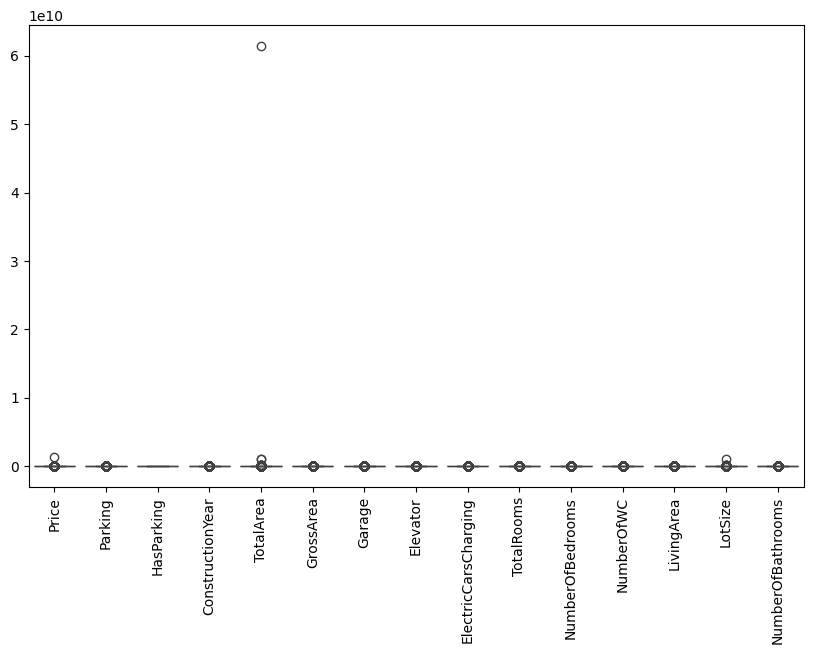

In [553]:
# Display the shape of the dataframe before removing outliers
print(df.shape)
#check outliers boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [554]:
# Select float64 columns
df_float64 = df.select_dtypes(include=['float64'])

# Calculate mean and standard deviation for each float64 column
mean_values = df_float64.mean()
std_values = df_float64.std()

# Define a function to identify outliers
def is_outlier(value, mean, std, threshold=3):
    return abs(value - mean) > threshold * std

# Identify and remove outliers
for column in df_float64.columns:
    mean = mean_values[column]
    std = std_values[column]
    df = df[~df[column].apply(is_outlier, args=(mean, std))]

(109063, 22)


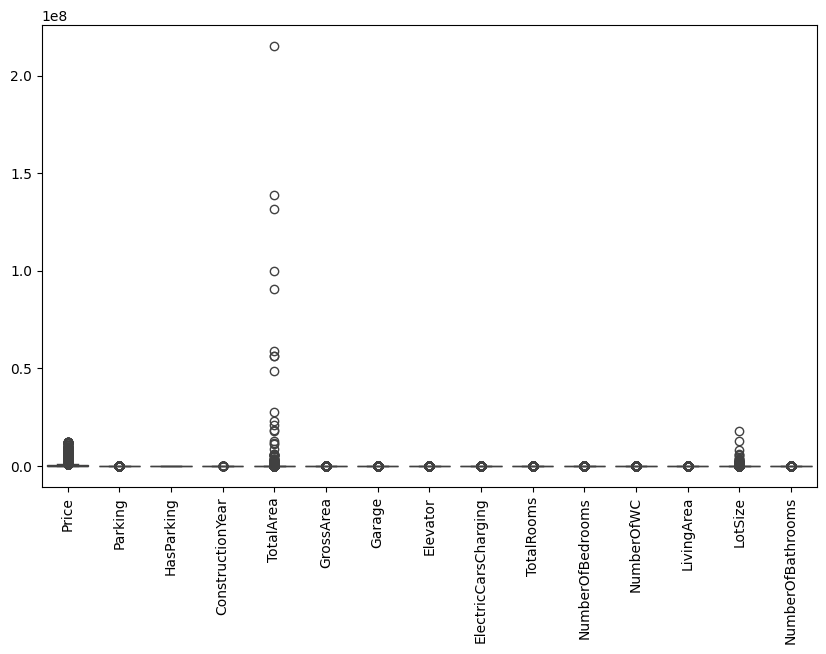

In [555]:
# Display the shape of the dataframe after removing outliers
print(df.shape)
# Check outliers boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

## Label Enconding

In [556]:
# Encode categorical variables
label_encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        print(column)
        df[column] = label_encoder.fit_transform(df[column].astype(str))

District
City
Town
Type
EnergyCertificate
Floor
HasParking
EnergyEfficiencyLevel
Garage
Elevator
ElectricCarsCharging


### Save the Label Enconder state

In [557]:
import pickle

# Save the LabelEncoder to a file
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
    
# To read it back
# # Load the LabelEncoder from the file
# with open('label_encoder.pkl', 'rb') as f:
#     loaded_label_encoder = pickle.load(f)

## Fill Missing values with KNNImputer

In [558]:
# Initialize KNNImputer
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
df_imputed

In [ ]:
# Save the KNNImputer to a file
df_imputed.to_csv('proceced_and_imputed.csv', index=False)
show_missing_data_with_percent(df)

In [559]:
# df_imputed = pd.read_csv('proceced_and_imputed.csv')
df = df_imputed

In [560]:
show_missing_data_with_percent(df)

                       Missing Values  Percentage
Price                               0        0.00
District                            0        0.00
City                                0        0.00
Town                                0        0.00
Type                                0        0.00
EnergyCertificate                   0        0.00
Floor                               0        0.00
Parking                             0        0.00
HasParking                          0        0.00
ConstructionYear                37833       34.69
TotalArea                        6573        6.03
GrossArea                       84208       77.21
EnergyEfficiencyLevel               0        0.00
Garage                              0        0.00
Elevator                            0        0.00
ElectricCarsCharging                0        0.00
TotalRooms                      48176       44.17
NumberOfBedrooms                77916       71.44
NumberOfWC                      67659       62.04


In [563]:
# Dataframe summary
def summary(df):
    print(f'data shape: {df.shape}')
    summ = pd.DataFrame(df.dtypes, columns=['Data Type'])
    summ['Missing#'] = df.isna().sum()
    summ['Missing%'] = (df.isna().sum())/len(df)
    summ['Dups'] = df.duplicated().sum()
    summ['Uniques'] = df.nunique().values
    summ['Count'] = df.count().values
    desc = pd.DataFrame(df.describe(include='all').transpose())
    summ['Min'] = desc['min'].values
    summ['Max'] = desc['max'].values
    summ['Average'] = desc['mean'].values
    summ['Standard Deviation'] = desc['std'].values
    summ['First Value'] = df.loc[0].values
    summ['Second Value'] = df.loc[1].values
    summ['Third Value'] = df.loc[2].values

    display(summ)

summary(df)

data shape: (109063, 22)


,Data Type,Missing#,Missing%,Dups,Uniques,Count,Min,Max,Average,Standard Deviation,First Value,Second Value,Third Value
Price,float64,0,0.000000,0,4374,109063,1.0,12500000.0,333968.641145,5.252505e+05,250000.0,9500.0,580000.0
District,int32,0,0.000000,0,24,109063,0.0,23.0,12.297525,6.662448e+00,6.0,6.0,6.0
City,int32,0,0.000000,0,271,109063,0.0,270.0,135.653155,7.562159e+01,222.0,4.0,261.0
Town,int32,0,0.000000,0,2244,109063,0.0,2243.0,1071.313195,6.443842e+02,1836.0,53.0,397.0
Type,int32,0,0.000000,0,21,109063,0.0,20.0,6.041884,5.237782e+00,0.0,0.0,0.0
EnergyCertificate,int32,0,0.000000,0,11,109063,0.0,10.0,6.275410,2.946132e+00,1.0,9.0,5.0
Floor,int32,0,0.000000,0,20,109063,0.0,19.0,15.817335,6.409896e+00,1.0,0.0,2.0
Parking,float64,0,0.000000,0,4,109063,0.0,3.0,0.559090,8.653075e-01,1.0,0.0,1.0
HasParking,int32,0,0.000000,0,3,109063,0.0,2.0,1.112238,8.573135e-01,1.0,0.0,1.0
ConstructionYear,float64,37833,0.346891,0,115,71230,1909.0,2024.0,1988.664467,2.603217e+01,NaN,1990.0,2003.0


In [564]:
# Dataframe summary

def summary(df):
    print(f'data shape: {df.shape}')
    summ = pd.DataFrame(df.dtypes, columns=['Data Type'])
    summ['Missing#'] = df.isna().sum()
    summ['Missing%'] = (df.isna().sum())/len(df)
    summ['Dups'] = df.duplicated().sum()
    summ['Uniques'] = df.nunique().values
    summ['Count'] = df.count().values
    desc = pd.DataFrame(df.describe(include='all').transpose())
    summ['Min'] = desc['min'].values
    summ['Max'] = desc['max'].values
    summ['Average'] = desc['mean'].values
    summ['Standard Deviation'] = desc['std'].values
    summ['First Value'] = df.loc[0].values
    summ['Second Value'] = df.loc[1].values
    summ['Third Value'] = df.loc[2].values

    display(summ)

summary(df)

data shape: (109063, 22)


,Data Type,Missing#,Missing%,Dups,Uniques,Count,Min,Max,Average,Standard Deviation,First Value,Second Value,Third Value
Price,float64,0,0.000000,0,4374,109063,1.0,12500000.0,333968.641145,5.252505e+05,250000.0,9500.0,580000.0
District,int32,0,0.000000,0,24,109063,0.0,23.0,12.297525,6.662448e+00,6.0,6.0,6.0
City,int32,0,0.000000,0,271,109063,0.0,270.0,135.653155,7.562159e+01,222.0,4.0,261.0
Town,int32,0,0.000000,0,2244,109063,0.0,2243.0,1071.313195,6.443842e+02,1836.0,53.0,397.0
Type,int32,0,0.000000,0,21,109063,0.0,20.0,6.041884,5.237782e+00,0.0,0.0,0.0
EnergyCertificate,int32,0,0.000000,0,11,109063,0.0,10.0,6.275410,2.946132e+00,1.0,9.0,5.0
Floor,int32,0,0.000000,0,20,109063,0.0,19.0,15.817335,6.409896e+00,1.0,0.0,2.0
Parking,float64,0,0.000000,0,4,109063,0.0,3.0,0.559090,8.653075e-01,1.0,0.0,1.0
HasParking,int32,0,0.000000,0,3,109063,0.0,2.0,1.112238,8.573135e-01,1.0,0.0,1.0
ConstructionYear,float64,37833,0.346891,0,115,71230,1909.0,2024.0,1988.664467,2.603217e+01,NaN,1990.0,2003.0


### Correlation Matrix

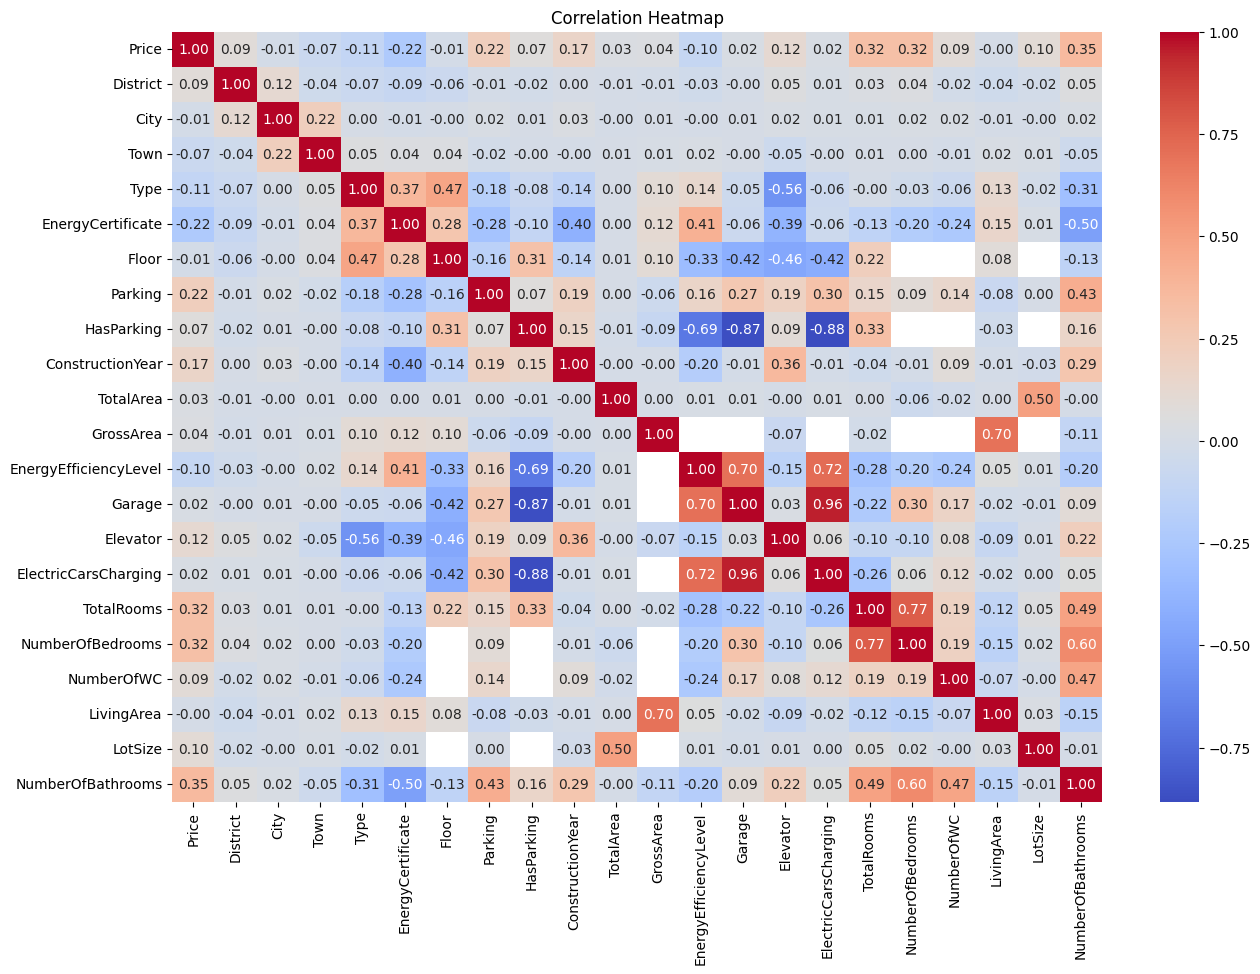

In [565]:
#correalation matrix
numerical_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(15, 10))
sns.heatmap(numerical_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()